In [141]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/lung-cancer-dataset/dataset.json
/kaggle/input/lung-cancer-dataset/dataset.csv


In [142]:
df = pd.read_json('/kaggle/input/lung-cancer-dataset/dataset.json')

In [143]:
df

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC_DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL_CONSUMING,COUGHING,SHORTNESS_OF_BREATH,SWALLOWING_DIFFICULTY,CHEST_PAIN,LUNG_CANCER
0,M,65,1,1,1,2,2,1,2,2,2,2,2,2,1,NO
1,F,55,1,2,2,1,1,2,2,2,1,1,1,2,2,NO
2,F,78,2,2,1,1,1,2,1,2,1,1,2,1,1,YES
3,M,60,2,1,1,1,2,1,2,1,1,2,1,2,2,YES
4,F,80,1,1,2,1,1,2,1,2,1,1,1,1,2,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,F,71,2,1,1,2,2,1,1,1,1,2,1,1,2,NO
2996,F,75,1,2,1,1,1,2,2,2,2,1,1,2,1,NO
2997,F,62,2,2,2,1,2,2,2,2,1,1,2,2,2,YES
2998,M,30,1,1,2,2,2,2,2,2,2,1,2,1,2,YES


In [144]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   GENDER                 3000 non-null   object
 1   AGE                    3000 non-null   int64 
 2   SMOKING                3000 non-null   int64 
 3   YELLOW_FINGERS         3000 non-null   int64 
 4   ANXIETY                3000 non-null   int64 
 5   PEER_PRESSURE          3000 non-null   int64 
 6   CHRONIC_DISEASE        3000 non-null   int64 
 7   FATIGUE                3000 non-null   int64 
 8   ALLERGY                3000 non-null   int64 
 9   WHEEZING               3000 non-null   int64 
 10  ALCOHOL_CONSUMING      3000 non-null   int64 
 11  COUGHING               3000 non-null   int64 
 12  SHORTNESS_OF_BREATH    3000 non-null   int64 
 13  SWALLOWING_DIFFICULTY  3000 non-null   int64 
 14  CHEST_PAIN             3000 non-null   int64 
 15  LUNG_CANCER          

In [145]:
for i in df.columns:
    print(f"{i} values : {pd.unique(df[i])}")

GENDER values : ['M' 'F']
AGE values : [65 55 78 60 80 58 70 74 77 67 35 79 39 62 64 66 76 48 33 47 50 36 37 51
 53 72 71 54 41 46 59 32 34 44 38 69 45 40 63 75 52 31 57 73 42 56 68 61
 30 49 43]
SMOKING values : [1 2]
YELLOW_FINGERS values : [1 2]
ANXIETY values : [1 2]
PEER_PRESSURE values : [2 1]
CHRONIC_DISEASE values : [2 1]
FATIGUE values : [1 2]
ALLERGY values : [2 1]
WHEEZING values : [2 1]
ALCOHOL_CONSUMING values : [2 1]
COUGHING values : [2 1]
SHORTNESS_OF_BREATH values : [2 1]
SWALLOWING_DIFFICULTY values : [2 1]
CHEST_PAIN values : [1 2]
LUNG_CANCER values : ['NO' 'YES']


In [146]:
df.describe()

,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC_DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL_CONSUMING,COUGHING,SHORTNESS_OF_BREATH,SWALLOWING_DIFFICULTY,CHEST_PAIN
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,55.169000,1.491000,1.514000,1.494000,1.499000,1.509667,1.489667,1.506667,1.497333,1.491333,1.510667,1.488000,1.489667,1.498667
std,14.723746,0.500002,0.499887,0.500047,0.500082,0.499990,0.499977,0.500039,0.500076,0.500008,0.499970,0.499939,0.499977,0.500082
min,30.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,42.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
50%,55.000000,1.000000,2.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000
75%,68.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
max,80.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000


#### --> As clear from the above cell that each column has no missing values. Also There are'nt any outliers like in Age column
so we don't need to make any imputations 

# Data Preprocessing
We need to map The categorical Data or we can say **ENCODE** the data So that we have an ease in the classification

In [147]:
data = df.copy()
data['GENDER'] = data.GENDER.map({'M':2,'F':1})
data.LUNG_CANCER = data.LUNG_CANCER.map({'YES':1,'NO':0})

In [148]:
data

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC_DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL_CONSUMING,COUGHING,SHORTNESS_OF_BREATH,SWALLOWING_DIFFICULTY,CHEST_PAIN,LUNG_CANCER
0,2,65,1,1,1,2,2,1,2,2,2,2,2,2,1,0
1,1,55,1,2,2,1,1,2,2,2,1,1,1,2,2,0
2,1,78,2,2,1,1,1,2,1,2,1,1,2,1,1,1
3,2,60,2,1,1,1,2,1,2,1,1,2,1,2,2,1
4,1,80,1,1,2,1,1,2,1,2,1,1,1,1,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,1,71,2,1,1,2,2,1,1,1,1,2,1,1,2,0
2996,1,75,1,2,1,1,1,2,2,2,2,1,1,2,1,0
2997,1,62,2,2,2,1,2,2,2,2,1,1,2,2,2,1
2998,2,30,1,1,2,2,2,2,2,2,2,1,2,1,2,1


# EDA

In [149]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: >

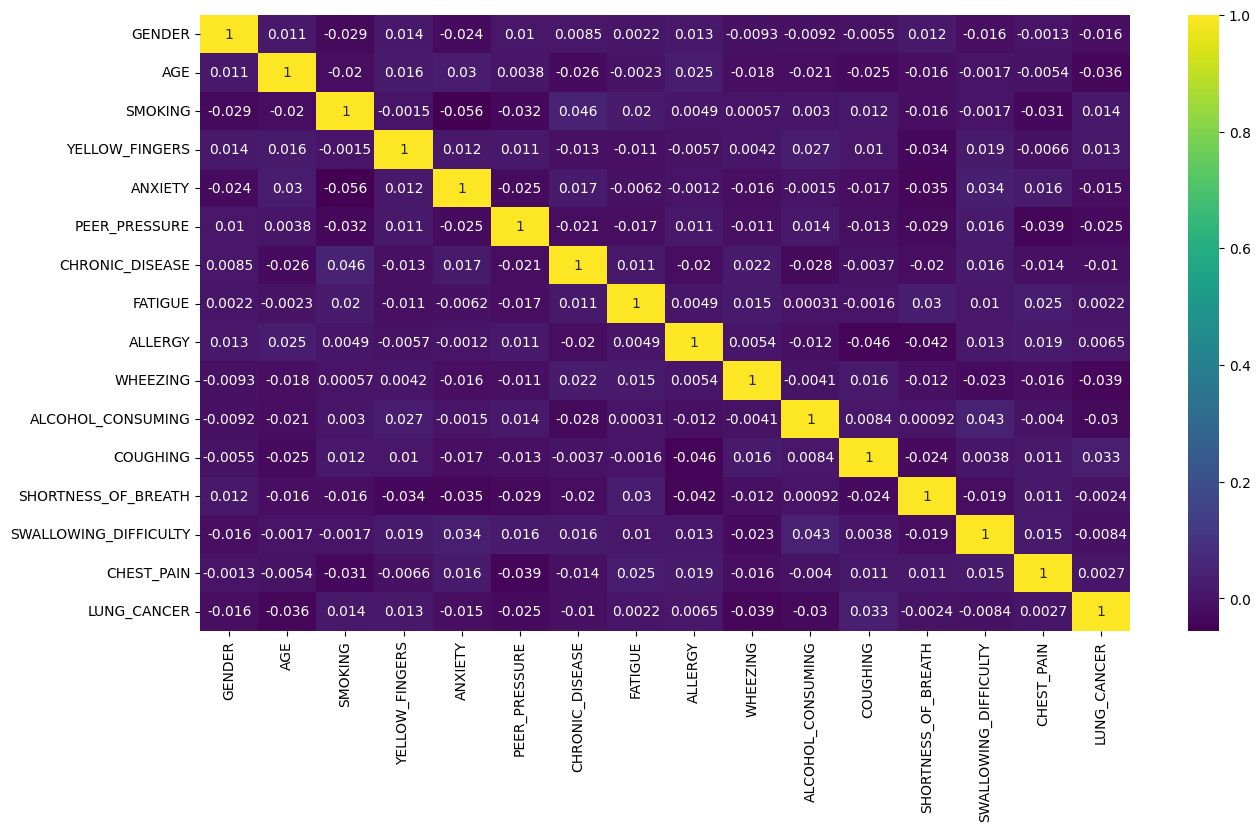

In [150]:
plt.figure(figsize = (15,8))
sns.heatmap(data.corr(), annot = True, cmap = 'viridis')

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0.5, 1.0, "Lung Cancer's distribution by AGE")

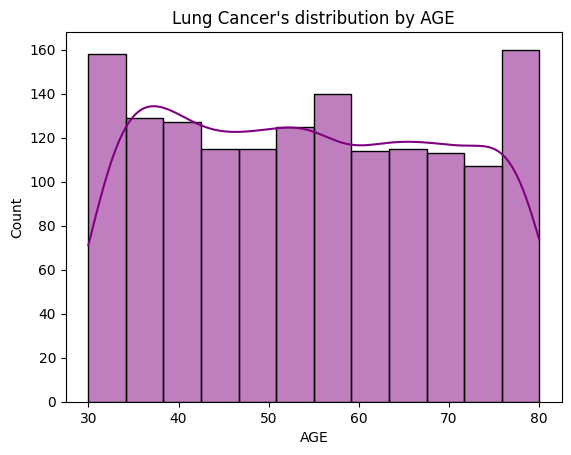

In [151]:
# Cancer distribution by age
sns.histplot(data[data['LUNG_CANCER'] == 1]['AGE'],kde = True,color= 'purple')
plt.title('Lung Cancer\'s distribution by AGE')

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


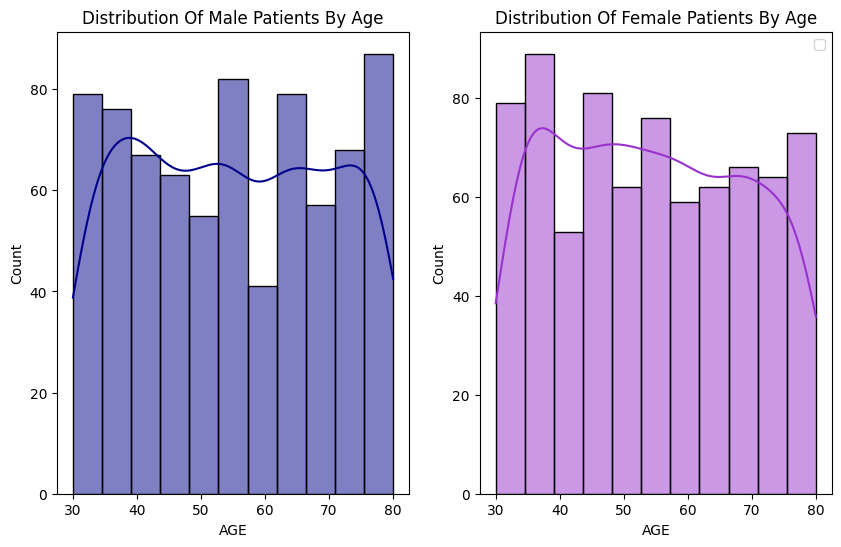

In [152]:
plt.figure(figsize = (10,6))
plt.subplot(1,2,1)
ax = sns.histplot(data = data[(data['LUNG_CANCER']== 1) & (data['GENDER']==2)]['AGE'],color = 'darkblue',kde = True,legend = 'Male')
plt.title('Distribution Of Male Patients By Age')
plt.subplot(1,2,2)
sns.histplot(data = data[(data['LUNG_CANCER']== 1) & (data['GENDER']==1)]['AGE'],kde = True,color = 'darkorchid',legend = 'Female')
plt.title('Distribution Of Female Patients By Age')
plt.legend(loc = 'upper right')

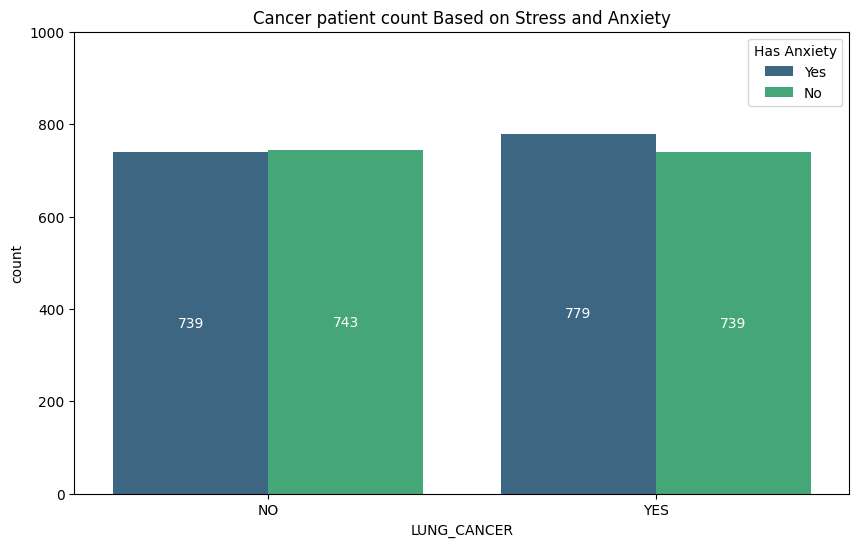

In [153]:
#CANCER distribution by ANXIETY

plt.figure(figsize = (10,6))
ax = sns.countplot(data = df,x= df.LUNG_CANCER,hue = 'ANXIETY',palette= 'viridis')
label = ['Yes', 'No']
plt.ylim(0,1000)
legend = plt.legend(loc = 'upper right',title = 'Has Anxiety')
for t, l in zip(legend.texts,label):
    t.set_text(l)
plt.title('Cancer patient count Based on Stress and Anxiety')
for bar in ax.patches:
    ax.annotate(format(bar.get_height(), '.0f'),
                (bar.get_x() + bar.get_width() / 2.,
                 bar.get_height()/2),
                 ha = 'center',
                 va = 'center',
                 color = 'white')

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0.5, 1.0, "Lung Cancer and Smoking's relation with age ")

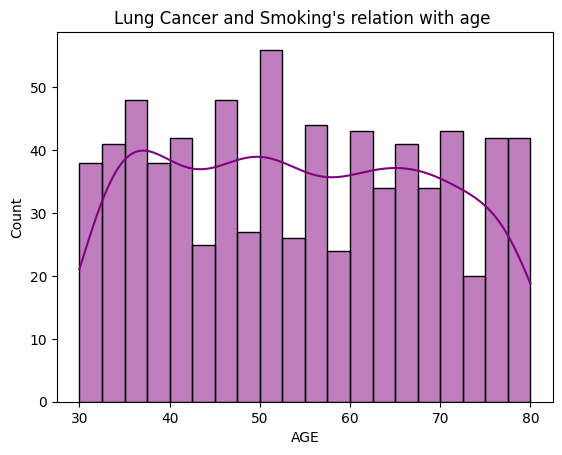

In [154]:
# Does smoking and alcohol and age increase likelihood of cancer
sns.histplot(data[ (data['SMOKING'] == 2) & (data['LUNG_CANCER']== 1) ]['AGE'],kde = True,bins = 20,color = 'purple')
plt.title('Lung Cancer and Smoking\'s relation with age ')


#### What Fraction Of Smoker have cancer ?

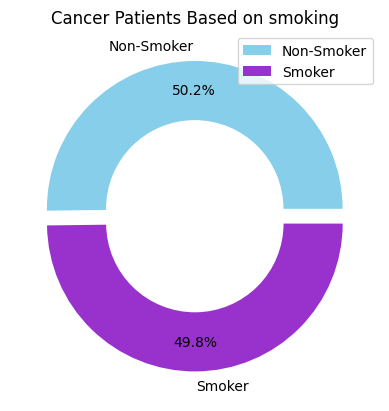

In [155]:
#What fraction of smokers have lung cancer
pie_data = data[data['LUNG_CANCER']==1]['SMOKING'].value_counts()
labels = []
for i in pie_data.index:
    if i == 1:
        labels.append('Non-Smoker')
    else:
        labels.append('Smoker')
explode = [0.05,0.05]
plt.pie(pie_data,labels = labels,autopct='%1.1f%%',colors = ['skyblue','darkorchid'],pctdistance = 0.8,wedgeprops={'width': 0.4},explode = explode)
plt.title('Cancer Patients Based on smoking')
plt.legend(labels = labels, loc = 'upper right')

#### What fraction of smokers have lung cancer

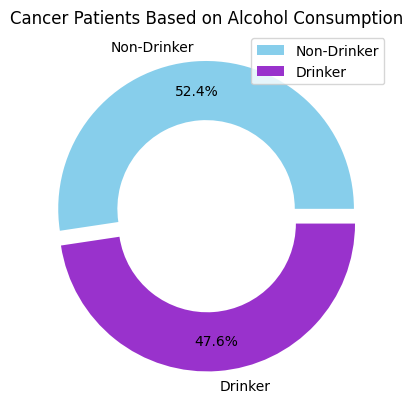

In [156]:

pie_data = data[data['LUNG_CANCER']==1]['ALCOHOL_CONSUMING'].value_counts()
labels = []
for i in pie_data.index:
    if i == 1:
        labels.append('Non-Drinker')
    else:
        labels.append('Drinker')
explode = [0.05,0.05]
plt.pie(pie_data,labels = labels,autopct='%1.1f%%',colors = ['skyblue','darkorchid'],pctdistance = 0.8,wedgeprops={'width': 0.4},explode = explode)
plt.title('Cancer Patients Based on Alcohol Consumption')
plt.legend(labels = labels,loc = 'upper right')


#### How many cancer patients had chronic disease

Text(0.5, 1.0, 'Cancer Patients Number Based on Whether They Had Chronic Conditions')

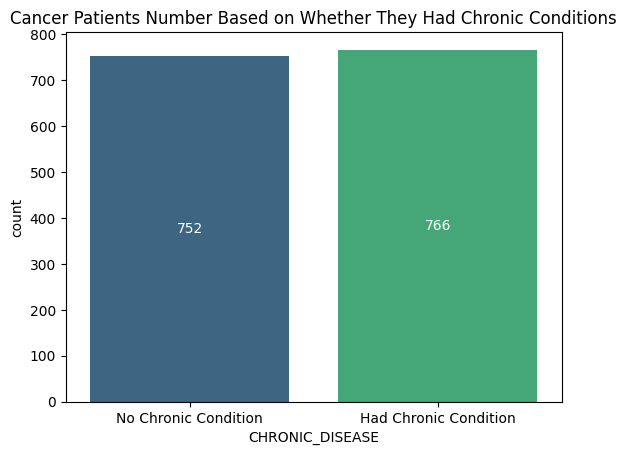

In [157]:
ax = sns.countplot(data = data, x=data[data['LUNG_CANCER']==1]['CHRONIC_DISEASE'],palette = 'viridis')
for bar in ax.patches:
    ax.annotate(format(bar.get_height(), '.0f'),
                (bar.get_x() + bar.get_width() / 2.,
                 bar.get_height()/2),
                 ha = 'center',
                 va = 'center',
                 color = 'white')
plt.xticks(ticks = [0,1],labels =  ['No Chronic Condition','Had Chronic Condition'])
plt.title('Cancer Patients Number Based on Whether They Had Chronic Conditions')

# Splitting The Data

In [158]:
from sklearn.model_selection import train_test_split, GridSearchCV,RandomizedSearchCV

In [159]:
X_train, X_test, y_train, y_test = train_test_split(data.iloc[:,:-1],data['LUNG_CANCER'],test_size = 0.2, shuffle = True )

# Let's Build Our Model

In this section we will try out multiple ML model algorithms to aim for the best scores
##### Now let us try different algorithms to get the best accuracy and f1 score for the classifications

## HyperParameter Tuning For RandomForests

In [160]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,accuracy_score,f1_score
from hyperopt import hp, tpe, fmin, Trials, STATUS_OK, space_eval

In [161]:
# Define set of parameters for testing
param_space = {
    'n_estimators': hp.quniform('n_estimators',100,1200,1),
    'criterion': hp.choice('criterion', ['gini','entropy']),
    'max_features':hp.choice('max_features', ['sqrt','log2']),
    'max_depth' : hp.quniform('max_depth', 1,30,2),
    'min_samples_split': hp.quniform('min_samples_split', 2,10,1),
    'min_samples_leaf' : hp.quniform('min_samples_leaf',2, 10,1),
    'ccp_alpha': hp.uniform('ccp_alpha',0.01,1),    
}

In [162]:
#Define Objective function to test the sample space on
from sklearn.model_selection import cross_val_score

def objective(space):
    
    clf = RandomForestClassifier(
        n_estimators = int(space['n_estimators']),
        criterion = space['criterion'],
        max_features = space['max_features'],
        max_depth = int(space['max_depth']),
        min_samples_leaf = int(space['min_samples_leaf']),
        min_samples_split = int(space['min_samples_split']),
        ccp_alpha = space['ccp_alpha'],
    )
    score  = cross_val_score(clf, X_train, y_train, cv = 3, scoring = 'accuracy').mean()
    return {'loss': -score, 'status': STATUS_OK}

# trials = Trials()

# best = fmin(
#     fn=objective,
#     space=param_space,
#     algo=tpe.suggest,
#     max_evals=100,
#     trials=trials
# )

In [163]:
# best_features = space_eval(param_space, best)
# best_features

In [164]:
forest = RandomForestClassifier(n_estimators = 800, n_jobs = -1, bootstrap = True, ccp_alpha = 0.01,criterion = 'entropy', max_features = 'log2',max_depth = 20,min_samples_leaf = 6, min_samples_split = 9)

In [165]:
forest.fit(X_train, y_train)

RandomForestClassifier(ccp_alpha=0.01, criterion='entropy', max_depth=20,
                       max_features='log2', min_samples_leaf=6,
                       min_samples_split=9, n_estimators=800, n_jobs=-1)

In [166]:
y_pred = forest.predict(X_test)

In [167]:
print(accuracy_score(y_test,y_pred))

0.5133333333333333


# Prediction Using XGBoost

In [168]:
from xgboost import XGBClassifier

In [169]:
xg_params = {
    'n_estimators' : hp.quniform('n_estimators', 100,1200, 100),
    'subsample' : hp.uniform('subsample',0.5,1),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1),
    'alpha' : hp.quniform('alpha', 1,100,1),
    'reg_lambda' : hp.quniform('reg_lambda', 1,100, 1),
    'max_depth' : hp.quniform('max_depth',1,10,1),
    'eta' : hp.uniform('eta', 0.001,1),
}

def xg_objective(space):
    clf = XGBClassifier(
        n_estimators = int(space['n_estimators']),
        subsample = np.round(space['subsample'], 2),
        colsample_bytree = np.round(space['colsample_bytree'], 2),
        reg_lambda = int(space['reg_lambda']),
        eta = float(space['eta']),
        max_depth = int(space['max_depth']),
        alpha = int(space['alpha'])     
    )
    
    score = cross_val_score(clf, X_train, y_train, cv = 3, scoring = 'accuracy').mean()
    return {'loss':-score, 'status':STATUS_OK}

In [170]:
# xg_trials = Trials()
# xg_best = fmin(
#     fn = xg_objective,
#     space = xg_params,
#     max_evals = 100,
#     algo = tpe.suggest,
#     trials = xg_trials
# )

In [171]:
# best_xg = space_eval(xg_params, xg_best)
# best_xg 

In [184]:
xgb = XGBClassifier(alpha= 11, colsample_bytree = 0.68433, eta = 0.8, max_depth = 8, n_estimators = 1200, reg_lambda = 73, subsample = 0.7, )
xgb.fit(X_train, y_train)
y_xgb = xgb.predict(X_test)
print('Accuracy For XGBoost is : ',accuracy_score(y_test, y_xgb))

Accuracy For XGBoost is :  0.515


# HyperParameter Tuning For CatBoost

In [173]:
from catboost import CatBoostClassifier

In [174]:
cat_params = {
    'l2_leaf_reg' : hp.quniform('l2_leaf_reg', 1, 100, 1),
    'n_estimators' : hp.quniform('n_estimators',100, 1200, 100),
    'learning_rate' : hp.uniform('learning_rate', 0.001,1),
    'min_data_in_leaf' : hp.quniform('min_data_in_leaf', 1,12,1),
    'max_depth' : hp.quniform('max_depth',1,15,1)
}

In [175]:
def cat_objective(space):
    clf = CatBoostClassifier(
        n_estimators = int(space['n_estimators']),
        learning_rate = float(space['learning_rate']),
        min_data_in_leaf = int(space['min_data_in_leaf']),
        max_depth = int(space['max_depth']),
        l2_leaf_reg = int(space['l2_leaf_reg'])
    )
    score = cross_val_score(clf, X_train, y_train, cv = 3, scoring = 'accuracy').mean()
    return {'loss': -score, 'status':STATUS_OK}

In [176]:
# cat_trials = Trials()
# cat_best = fmin(
#     fn = cat_objective,
#     space = cat_params,
#     algo = tpe.suggest,
#     trials = cat_trials,
#     max_evals = 15
# )

In [177]:
# best_catboost = space_eval(cat_params, cat_best)
# best_catboost

In [181]:
catBooster = CatBoostClassifier(l2_leaf_reg = 58, learning_rate = 0.98, min_data_in_leaf = 7, max_depth = 7, n_estimators = 1000)
catBooster.fit(X_train, y_train)
y_cat = catBooster.predict(X_test)

0:	learn: 0.6658529	total: 2.74ms	remaining: 2.74s
1:	learn: 0.6399626	total: 5.41ms	remaining: 2.7s
2:	learn: 0.6265803	total: 7.88ms	remaining: 2.62s
3:	learn: 0.6126396	total: 10.4ms	remaining: 2.58s
4:	learn: 0.6010275	total: 12.8ms	remaining: 2.55s
5:	learn: 0.5832566	total: 15.3ms	remaining: 2.53s
6:	learn: 0.5790623	total: 17.6ms	remaining: 2.49s
7:	learn: 0.5739845	total: 20.2ms	remaining: 2.5s
8:	learn: 0.5629821	total: 22.7ms	remaining: 2.5s
9:	learn: 0.5499805	total: 25.1ms	remaining: 2.49s
10:	learn: 0.5399286	total: 27.5ms	remaining: 2.47s
11:	learn: 0.5285991	total: 29.9ms	remaining: 2.46s
12:	learn: 0.5231012	total: 32.4ms	remaining: 2.46s
13:	learn: 0.5160553	total: 34.9ms	remaining: 2.46s
14:	learn: 0.5070154	total: 37.4ms	remaining: 2.45s
15:	learn: 0.4991880	total: 39.8ms	remaining: 2.45s
16:	learn: 0.4932457	total: 42.2ms	remaining: 2.44s
17:	learn: 0.4820128	total: 44.7ms	remaining: 2.44s
18:	learn: 0.4695619	total: 47.1ms	remaining: 2.43s
19:	learn: 0.4620018	tota

In [182]:
print('Accuracy for CatBoost Model is : ', accuracy_score(y_test, y_cat))

Accuracy for CatBoost Model is :  0.5183333333333333


# HyperParameter Tuning For LightGBM

In [ ]:
from lightgbm import LGBMClassifier

In [ ]:
light_params = { 
    'n_estimators' : hp.quniform('n_estimators', 100, 1200, 100),
    'lambda_l1' : hp.quniform('lambda_l1',1, 100, 1),
    'lambda_l2' : hp.quniform('lambda_l2',1, 100, 1),
    'feature_fraction' : hp.uniform('feature_fraction', 0.5,1),
    'learning_rate' : hp.uniform('learning_rate',0.001, 1),
    'max_depth' : hp.quniform('max_depth', 1, 15,1)
}

In [ ]:
def light_objective(space):
    
    clf = LGBMClassifier(
        n_estimators = int(space['n_estimators']),
        lambda_l1 = int(space['lambda_l1']),
        lambda_l2 = int(space['lambda_l2']),
        learning_rate = float(space['learning_rate']),
        max_depth = int(space['max_depth']),
        feature_fraction = np.round(space['feature_fraction'], 2)
    )
    
    score = cross_val_score(clf, X_train, y_train, cv = 3, scoring = 'accuracy').mean()
    return {'loss': -score, 'status': STATUS_OK}

In [ ]:
# light_trials = Trials()
# light_best = fmin(
#     fn = light_objective,
#     algo = tpe.suggest,
#     space = light_params,
#     max_evals = 10,
#     trials = light_trials
# )

In [ ]:
# best_lightBoost = space_eval(light_params, light_best)
# best_lightBoost

In [ ]:
lightBooster = LGBMClassifier(feature_fraction = 0.978, lambda_l1 = 10, lambda_l2 = 6, learning_rate = 0.52, max_depth = 8, n_estimators = 900,verbose = -1)
lightBooster.fit(X_train,y_train)
y_light = lightBooster.predict(X_test)


In [185]:
print('Accuracy for LightGBM is : ',accuracy_score(y_test, y_light))

Accuracy for LightGBM is :  0.5216666666666666


# Final Prediction Using Stack Classifier

### We know that when boosting models perform intermediately then we have 2 option
#### 1. Use Voting Ensemble
#### 2. Use Stack Ensemble

In [186]:
from sklearn.ensemble import StackingClassifier

In [187]:
estimators = [
    ('light',lightBooster),
    ('xgb',xgb),
    ('catBooster',catBooster)
]

In [192]:
final_model = xgb

In [ ]:
stack = StackingClassifier(estimators = estimators, final_estimator = final_model, cv = 3, n_jobs = -1, verbose = 1)
stack.fit(X_train, y_train)
y_stack = stack.predict(X_test)


In [194]:
print('Accuracy By Stack Ensemble Is : ',accuracy_score(y_test,y_stack))

Accuracy By Stack Ensemble Is :  0.5116666666666667


# Prediction By Voting Classifier

In [200]:
voter_estimators = [
    ('light',lightBooster),
    ('xgb',xgb),
    ('catBooster',catBooster),
    ('rf',forest)
]

In [201]:
from sklearn.ensemble import VotingClassifier

In [ ]:
voter = VotingClassifier(estimators = voter_estimators, verbose = 1)
voter.fit(X_train,y_train)
y_vote = voter.predict(X_test)

In [204]:
print('Accuracy Using Voting Classifier', accuracy_score(y_test,y_stack))

Accuracy Using Voting Classifier 0.5116666666666667
